# 롤 필승전략

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# 데이터셋 준비

In [2]:
base_path = '.'
filepath = os.path.join(base_path, 'high_diamond_ranked_10min.csv')
filepath

'./high_diamond_ranked_10min.csv'

In [3]:
pd.set_option('display.max_columns', None)
df = pd.read_csv(filepath)
df

,gameId,blueWins,blueWardsPlaced,blueWardsDestroyed,blueFirstBlood,blueKills,blueDeaths,blueAssists,blueEliteMonsters,blueDragons,blueHeralds,blueTowersDestroyed,blueTotalGold,blueAvgLevel,blueTotalExperience,blueTotalMinionsKilled,blueTotalJungleMinionsKilled,blueGoldDiff,blueExperienceDiff,blueCSPerMin,blueGoldPerMin,redWardsPlaced,redWardsDestroyed,redFirstBlood,redKills,redDeaths,redAssists,redEliteMonsters,redDragons,redHeralds,redTowersDestroyed,redTotalGold,redAvgLevel,redTotalExperience,redTotalMinionsKilled,redTotalJungleMinionsKilled,redGoldDiff,redExperienceDiff,redCSPerMin,redGoldPerMin
0,4519157822,0,28,2,1,9,6,11,0,0,0,0,17210,6.6,17039,195,36,643,-8,19.5,1721.0,15,6,0,6,9,8,0,0,0,0,16567,6.8,17047,197,55,-643,8,19.7,1656.7
1,4523371949,0,12,1,0,5,5,5,0,0,0,0,14712,6.6,16265,174,43,-2908,-1173,17.4,1471.2,12,1,1,5,5,2,2,1,1,1,17620,6.8,17438,240,52,2908,1173,24.0,1762.0
2,4521474530,0,15,0,0,7,11,4,1,1,0,0,16113,6.4,16221,186,46,-1172,-1033,18.6,1611.3,15,3,1,11,7,14,0,0,0,0,17285,6.8,17254,203,28,1172,1033,20.3,1728.5
3,4524384067,0,43,1,0,4,5,5,1,0,1,0,15157,7.0,17954,201,55,-1321,-7,20.1,1515.7,15,2,1,5,4,10,0,0,0,0,16478,7.0,17961,235,47,1321,7,23.5,1647.8
4,4436033771,0,75,4,0,6,6,6,0,0,0,0,16400,7.0,18543,210,57,-1004,230,21.0,1640.0,17,2,1,6,6,7,1,1,0,0,17404,7.0,18313,225,67,1004,-230,22.5,1740.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9874,4527873286,1,17,2,1,7,4,5,1,1,0,0,17765,7.2,18967,211,69,2519,2469,21.1,1776.5,46,3,0,4,7,7,0,0,0,0,15246,6.8,16498,229,34,-2519,-2469,22.9,1524.6
9875,4527797466,1,54,0,0,6,4,8,1,1,0,0,16238,7.2,19255,233,48,782,888,23.3,1623.8,12,21,1,4,6,3,0,0,0,0,15456,7.0,18367,206,56,-782,-888,20.6,1545.6
9876,4527713716,0,23,1,0,6,7,5,0,0,0,0,15903,7.0,18032,210,45,-2416,-1877,21.0,1590.3,14,0,1,7,6,11,1,1,0,0,18319,7.4,19909,261,60,2416,1877,26.1,1831.9
9877,4527628313,0,14,4,1,2,3,3,1,1,0,0,14459,6.6,17229,224,48,-839,-1085,22.4,1445.9,66,4,0,3,2,1,0,0,0,0,15298,7.2,18314,247,40,839,1085,24.7,1529.8


## 데이터 소개
- 이번 주제는 League of Legends Diamond Ranked Games (10 min) 데이터셋을 사용합니다.

    
- 다음 1개의 csv 파일을 사용합니다.
    - high_diamond_ranked_10min.csv
    
    
- 각 파일의 컬럼은 아래와 같습니다.
    - gameId: 게임 판의 고유 ID
    - **blueWins**: 블루팀의 승리 여부 (0: 패배, 1: 승리)  <-- ⭐타겟값
    - xxxWardsPlaced: xxx팀에서 설치한 와드의 수
    - xxxWardsDestroyed: xxx팀에서 파괴한 와드의 수
    - xxxFirstBlood: xxx팀의 첫번째 킬 달성 여부
    - xxxKills: xxx팀의 킬 수
    - xxxDeaths: xxx팀의 죽음 수
    - xxxAssists: xxx팀의 어시스트 수
    - xxxEliteMonsters: xxx팀이 죽인 엘리트 몬스터 수
    - xxxDragons: xxx팀이 죽인 용의 수
    - xxxHeralds: xxx팀이 죽인 전령의 수
    - xxxTowersDestroyed: xxx팀이 파괴한 탑의 수
    - xxxTotalGold: xxx팀의 전체 획득 골드
    - xxxAvgLevel: xxx팀의 평균 레벨
    - xxxTotalExperience: xxx팀의 총 경험치 획득량
    - xxxTotalMinionsKilled: xxx팀의 총 미니언 킬 수
    - xxxTotalJungleMinionsKilled: xxx팀의 총 정글 미니언 킬 수
    - xxxGoldDiff: xxx팀과 다른 팀 간의 골드 획득량 차이
    - xxxExperienceDiff: xxx팀과 다른 팀과의 경험치 획득량 차이
    - xxxCSPerMin: xxx팀의 분당 CS 스코어
    - xxxGoldPerMin: xxx팀의 분당 골드 획득량
      
        
- 데이터 출처: https://www.kaggle.com/bobbyscience/league-of-legends-diamond-ranked-games-10-min

# 기초 통계 분석 - 각 컬럼 분석

In [4]:
df.head()

,gameId,blueWins,blueWardsPlaced,blueWardsDestroyed,blueFirstBlood,blueKills,blueDeaths,blueAssists,blueEliteMonsters,blueDragons,blueHeralds,blueTowersDestroyed,blueTotalGold,blueAvgLevel,blueTotalExperience,blueTotalMinionsKilled,blueTotalJungleMinionsKilled,blueGoldDiff,blueExperienceDiff,blueCSPerMin,blueGoldPerMin,redWardsPlaced,redWardsDestroyed,redFirstBlood,redKills,redDeaths,redAssists,redEliteMonsters,redDragons,redHeralds,redTowersDestroyed,redTotalGold,redAvgLevel,redTotalExperience,redTotalMinionsKilled,redTotalJungleMinionsKilled,redGoldDiff,redExperienceDiff,redCSPerMin,redGoldPerMin
0,4519157822,0,28,2,1,9,6,11,0,0,0,0,17210,6.6,17039,195,36,643,-8,19.5,1721.0,15,6,0,6,9,8,0,0,0,0,16567,6.8,17047,197,55,-643,8,19.7,1656.7
1,4523371949,0,12,1,0,5,5,5,0,0,0,0,14712,6.6,16265,174,43,-2908,-1173,17.4,1471.2,12,1,1,5,5,2,2,1,1,1,17620,6.8,17438,240,52,2908,1173,24.0,1762.0
2,4521474530,0,15,0,0,7,11,4,1,1,0,0,16113,6.4,16221,186,46,-1172,-1033,18.6,1611.3,15,3,1,11,7,14,0,0,0,0,17285,6.8,17254,203,28,1172,1033,20.3,1728.5
3,4524384067,0,43,1,0,4,5,5,1,0,1,0,15157,7.0,17954,201,55,-1321,-7,20.1,1515.7,15,2,1,5,4,10,0,0,0,0,16478,7.0,17961,235,47,1321,7,23.5,1647.8
4,4436033771,0,75,4,0,6,6,6,0,0,0,0,16400,7.0,18543,210,57,-1004,230,21.0,1640.0,17,2,1,6,6,7,1,1,0,0,17404,7.0,18313,225,67,1004,-230,22.5,1740.4


In [5]:
df[['blueGoldDiff', 'redGoldDiff']]

,blueGoldDiff,redGoldDiff
0,643,-643
1,-2908,2908
2,-1172,1172
3,-1321,1321
4,-1004,1004
...,...,...
9874,2519,-2519
9875,782,-782
9876,-2416,2416
9877,-839,839


In [6]:
"""
↑ 컬럼의 수가 꽤 많아졌다  (40컬럼)...  이를 효과적으로 볼 필요도 있을거 같다.
gameId 는 무시해도 될듯 하고

초반에 blue 측 컬럼들,   그리고 중반이후 red 측 컬럼들.. 로 구성되어 있다.

blueWins 는 0, 1
blueEliteMonsters 도 0, 1 일까?
  => 확인해봐야 겠다.  정말, 0 과 1 만 있는지 아니면 그 밖에 다른 정수값도 있는지 확인해봐야 한다

blueAvgLevel :
  최대 레벨이 18.
  10분안에 레벨을 몇까지 올렸는지에 대한 평균 레벨.
  웬지 10 이하의 값들일거 같다.


전체적으로 앞쪽의 컬럼이 'blue' 쪽 정보이고
오른쪽의 컬럼이 'red' 쪽 정보이다.  그러다 보니
 양측에 중복된 데이터도 있을것이다.
가령.

bludGoldDiff :
    아마 regGoldDiff 와 부호가 다른 관계에 있을듯.  즉 중복된 정보일 가능성이 크다.
    이 경우 한가지만 사용해도 될것이다.
    multi-core linearity 를 가지는 값들은 drop 해서 제거할 필요가 있어 보인다.

"""
None

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9879 entries, 0 to 9878
Data columns (total 40 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   gameId                        9879 non-null   int64  
 1   blueWins                      9879 non-null   int64  
 2   blueWardsPlaced               9879 non-null   int64  
 3   blueWardsDestroyed            9879 non-null   int64  
 4   blueFirstBlood                9879 non-null   int64  
 5   blueKills                     9879 non-null   int64  
 6   blueDeaths                    9879 non-null   int64  
 7   blueAssists                   9879 non-null   int64  
 8   blueEliteMonsters             9879 non-null   int64  
 9   blueDragons                   9879 non-null   int64  
 10  blueHeralds                   9879 non-null   int64  
 11  blueTowersDestroyed           9879 non-null   int64  
 12  blueTotalGold                 9879 non-null   int64  
 13  blueAvgLevel  

In [8]:
"""
9879 개 데이터 모두가 non-null 이다 (결측치 없다, 데이터 분석하는 입장에선 반갑다.)
null  이 있다면,  '제거' 할지 '치환' 할지 고민도 해보고 여러 경우를 실험해 봐야 할것이다.

dtype 은 전부 숫자 타입이지만,  수치형데이터로 다룰지 혹은 분류형 데이터로 다루어야 할지 고민해봐야 겠다
"""
None

In [9]:
df.describe()
# 이상치,
# balanced vs imbalanced

,gameId,blueWins,blueWardsPlaced,blueWardsDestroyed,blueFirstBlood,blueKills,blueDeaths,blueAssists,blueEliteMonsters,blueDragons,blueHeralds,blueTowersDestroyed,blueTotalGold,blueAvgLevel,blueTotalExperience,blueTotalMinionsKilled,blueTotalJungleMinionsKilled,blueGoldDiff,blueExperienceDiff,blueCSPerMin,blueGoldPerMin,redWardsPlaced,redWardsDestroyed,redFirstBlood,redKills,redDeaths,redAssists,redEliteMonsters,redDragons,redHeralds,redTowersDestroyed,redTotalGold,redAvgLevel,redTotalExperience,redTotalMinionsKilled,redTotalJungleMinionsKilled,redGoldDiff,redExperienceDiff,redCSPerMin,redGoldPerMin
count,9.879000e+03,9879.000000,9879.000000,9879.000000,9879.000000,9879.000000,9879.000000,9879.000000,9879.000000,9879.000000,9879.000000,9879.000000,9879.000000,9879.000000,9879.000000,9879.000000,9879.000000,9879.000000,9879.000000,9879.000000,9879.000000,9879.000000,9879.000000,9879.000000,9879.000000,9879.000000,9879.000000,9879.000000,9879.000000,9879.000000,9879.000000,9879.000000,9879.000000,9879.000000,9879.000000,9879.000000,9879.000000,9879.000000,9879.000000,9879.000000
mean,4.500084e+09,0.499038,22.288288,2.824881,0.504808,6.183925,6.137666,6.645106,0.549954,0.361980,0.187974,0.051422,16503.455512,6.916004,17928.110133,216.699565,50.509667,14.414111,-33.620306,21.669956,1650.345551,22.367952,2.723150,0.495192,6.137666,6.183925,6.662112,0.573135,0.413098,0.160036,0.043021,16489.041401,6.925316,17961.730438,217.349226,51.313088,-14.414111,33.620306,21.734923,1648.904140
std,2.757328e+07,0.500024,18.019177,2.174998,0.500002,3.011028,2.933818,4.064520,0.625527,0.480597,0.390712,0.244369,1535.446636,0.305146,1200.523764,21.858437,9.898282,2453.349179,1920.370438,2.185844,153.544664,18.457427,2.138356,0.500002,2.933818,3.011028,4.060612,0.626482,0.492415,0.366658,0.216900,1490.888406,0.305311,1198.583912,21.911668,10.027885,2453.349179,1920.370438,2.191167,149.088841
min,4.295358e+09,0.000000,5.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,10730.000000,4.600000,10098.000000,90.000000,0.000000,-10830.000000,-9333.000000,9.000000,1073.000000,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,11212.000000,4.800000,10465.000000,107.000000,4.000000,-11467.000000,-8348.000000,10.700000,1121.200000
25%,4.483301e+09,0.000000,14.000000,1.000000,0.000000,4.000000,4.000000,4.000000,0.000000,0.000000,0.000000,0.000000,15415.500000,6.800000,17168.000000,202.000000,44.000000,-1585.500000,-1290.500000,20.200000,1541.550000,14.000000,1.000000,0.000000,4.000000,4.000000,4.000000,0.000000,0.000000,0.000000,0.000000,15427.500000,6.800000,17209.500000,203.000000,44.000000,-1596.000000,-1212.000000,20.300000,1542.750000
50%,4.510920e+09,0.000000,16.000000,3.000000,1.000000,6.000000,6.000000,6.000000,0.000000,0.000000,0.000000,0.000000,16398.000000,7.000000,17951.000000,218.000000,50.000000,14.000000,-28.000000,21.800000,1639.800000,16.000000,2.000000,0.000000,6.000000,6.000000,6.000000,0.000000,0.000000,0.000000,0.000000,16378.000000,7.000000,17974.000000,218.000000,51.000000,-14.000000,28.000000,21.800000,1637.800000
75%,4.521733e+09,1.000000,20.000000,4.000000,1.000000,8.000000,8.000000,9.000000,1.000000,1.000000,0.000000,0.000000,17459.000000,7.200000,18724.000000,232.000000,56.000000,1596.000000,1212.000000,23.200000,1745.900000,20.000000,4.000000,1.000000,8.000000,8.000000,9.000000,1.000000,1.000000,0.000000,0.000000,17418.500000,7.200000,18764.500000,233.000000,57.000000,1585.500000,1290.500000,23.300000,1741.850000
max,4.527991e+09,1.000000,250.000000,27.000000,1.000000,22.000000,22.000000,29.000000,2.000000,1.000000,1.000000,4.000000,23701.000000,8.000000,22224.000000,283.000000,92.000000,11467.000000,8348.000000,28.300000,2370.100000,276.000000,24.000000,1.000000,22.000000,22.000000,28.000000,2.000000,1.000000,1.000000,2.000000,22732.000000,8.200000,22269.000000,289.000000,92.000000,10830.000000,9333.000000,28.900000,2273.200000


In [10]:
"""
blueWins : min, max, maen 을 보면 거의 balanced 데이터임을 알수 있다.

blueFirstBlood:
  mean : 양쪽다 even 하게 0.5 로 갈라짐.

blueDragons 가 blueHeralds 의 min, max 는 0, 1 이다.
  => 시간이 10분으로 제한되어 있어서 그런가 보다.  (과연 이를 '분류형'으로 보아야 할지도 고민.)

blueDragons 가 blueHeralds 가 0.5 보다 낮다!
redDragons 이 살짝 높다.
  => 이는 맵이 정확하게 대칭이 아니라 그런듯 하다.  dragon 이 red 쪽에 치우쳐 있는듯? (추측)


대부분 수치데이터다, -> 나중에 히스토그램등을 통해서 들여보아야 할거다

"""
None

In [11]:
df.corr()

,gameId,blueWins,blueWardsPlaced,blueWardsDestroyed,blueFirstBlood,blueKills,blueDeaths,blueAssists,blueEliteMonsters,blueDragons,blueHeralds,blueTowersDestroyed,blueTotalGold,blueAvgLevel,blueTotalExperience,blueTotalMinionsKilled,blueTotalJungleMinionsKilled,blueGoldDiff,blueExperienceDiff,blueCSPerMin,blueGoldPerMin,redWardsPlaced,redWardsDestroyed,redFirstBlood,redKills,redDeaths,redAssists,redEliteMonsters,redDragons,redHeralds,redTowersDestroyed,redTotalGold,redAvgLevel,redTotalExperience,redTotalMinionsKilled,redTotalJungleMinionsKilled,redGoldDiff,redExperienceDiff,redCSPerMin,redGoldPerMin
gameId,1.000000,0.000985,0.005361,-0.012057,-0.011577,-0.038993,-0.013160,-0.023329,0.016599,0.008962,0.015551,-0.007467,-0.033754,-0.040956,-0.040852,-0.002917,-0.004193,-0.014670,-0.012315,-0.002917,-0.033754,0.007405,-0.001197,0.011577,-0.013160,-0.038993,-0.008664,0.017296,0.017416,0.006163,0.003557,-0.010622,-0.012419,-0.021187,-0.005118,0.006040,0.014670,0.012315,-0.005118,-0.010622
blueWins,0.000985,1.000000,0.000087,0.044247,0.201769,0.337358,-0.339297,0.276685,0.221944,0.213768,0.092385,0.115566,0.417213,0.357820,0.396141,0.224909,0.131445,0.511119,0.489558,0.224909,0.417213,-0.023671,-0.055400,-0.201769,-0.339297,0.337358,-0.271047,-0.221551,-0.209516,-0.097172,-0.103696,-0.411396,-0.352127,-0.387588,-0.212171,-0.110994,-0.511119,-0.489558,-0.212171,-0.411396
blueWardsPlaced,0.005361,0.000087,1.000000,0.034447,0.003228,0.018138,-0.002612,0.033217,0.019892,0.017676,0.010104,0.009462,0.019725,0.034349,0.031719,-0.033925,0.010501,0.015800,0.027943,-0.033925,0.019725,-0.012906,0.115549,-0.003228,-0.002612,0.018138,-0.009009,-0.022817,-0.020121,-0.011964,-0.008225,-0.005685,-0.008882,-0.013000,-0.012395,0.001224,-0.015800,-0.027943,-0.012395,-0.005685
blueWardsDestroyed,-0.012057,0.044247,0.034447,1.000000,0.017717,0.033748,-0.073182,0.067793,0.041700,0.040504,0.016940,-0.009150,0.060054,0.060294,0.067462,0.111028,-0.023452,0.078585,0.077946,0.111028,0.060054,0.135966,0.123919,-0.017717,-0.073182,0.033748,-0.046212,-0.034509,-0.034439,-0.012712,-0.023943,-0.067467,-0.059090,-0.057314,0.040023,-0.035732,-0.078585,-0.077946,0.040023,-0.067467
blueFirstBlood,-0.011577,0.201769,0.003228,0.017717,1.000000,0.269425,-0.247929,0.229485,0.151603,0.134309,0.077509,0.083316,0.312058,0.177617,0.190365,0.125642,0.018190,0.378511,0.240665,0.125642,0.312058,-0.019142,-0.043304,-1.000000,-0.247929,0.269425,-0.201140,-0.141627,-0.135327,-0.060246,-0.069584,-0.301479,-0.182602,-0.194920,-0.156711,-0.024559,-0.378511,-0.240665,-0.156711,-0.301479
blueKills,-0.038993,0.337358,0.018138,0.033748,0.269425,1.000000,0.004044,0.813667,0.178540,0.170436,0.076195,0.180314,0.888751,0.434867,0.472155,-0.030880,-0.112506,0.654148,0.583730,-0.030880,0.888751,-0.034239,-0.092278,-0.269425,0.004044,1.000000,-0.020344,-0.224564,-0.207949,-0.104423,-0.082491,-0.161127,-0.412219,-0.462333,-0.472203,-0.214454,-0.654148,-0.583730,-0.472203,-0.161127
blueDeaths,-0.013160,-0.339297,-0.002612,-0.073182,-0.247929,0.004044,1.000000,-0.026372,-0.204764,-0.188852,-0.095527,-0.071441,-0.162572,-0.414755,-0.460122,-0.468560,-0.228102,-0.640000,-0.577613,-0.468560,-0.162572,0.008102,0.038672,0.247929,1.000000,0.004044,0.804023,0.163340,0.150746,0.076639,0.156780,0.885728,0.433383,0.464584,-0.040521,-0.100271,0.640000,0.577613,-0.040521,0.885728
blueAssists,-0.023329,0.276685,0.033217,0.067793,0.229485,0.813667,-0.026372,1.000000,0.149043,0.170873,0.028434,0.123663,0.748352,0.292661,0.303022,-0.062035,-0.134023,0.549761,0.437002,-0.062035,0.748352,-0.032474,-0.064501,-0.229485,-0.026372,0.813667,-0.007481,-0.182985,-0.189563,-0.058074,-0.060880,-0.133948,-0.356928,-0.396652,-0.337515,-0.160915,-0.549761,-0.437002,-0.337515,-0.133948
blueEliteMonsters,0.016599,0.221944,0.019892,0.041700,0.151603,0.178540,-0.204764,0.149043,1.000000,0.781039,0.640271,0.166644,0.239396,0.203530,0.232774,0.118762,0.198378,0.281464,0.263991,0.118762,0.239396,-0.017292,-0.005288,-0.151603,-0.204764,

<Axes: >

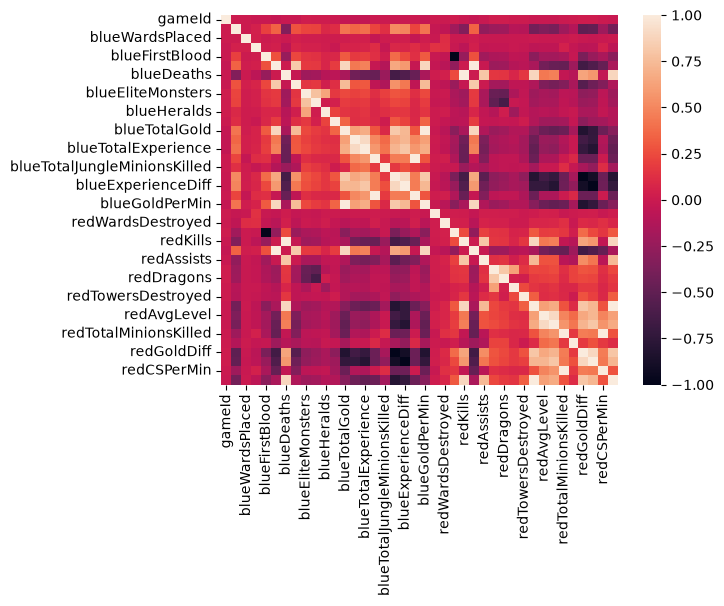

In [12]:
# DataFrame의 corr() 메소드와 Seaborn의 heatmap() 메소드를 이용하여
# Pearson's correlation (피어슨 상관계수) 시각화하기

# ※ 피어슨 상관계수 란?
#    두 변수의 '선형적' 상관 관계를 -1 ~ +1 사이의 값으로 계량화한 수치
#

sns.heatmap(df.corr())



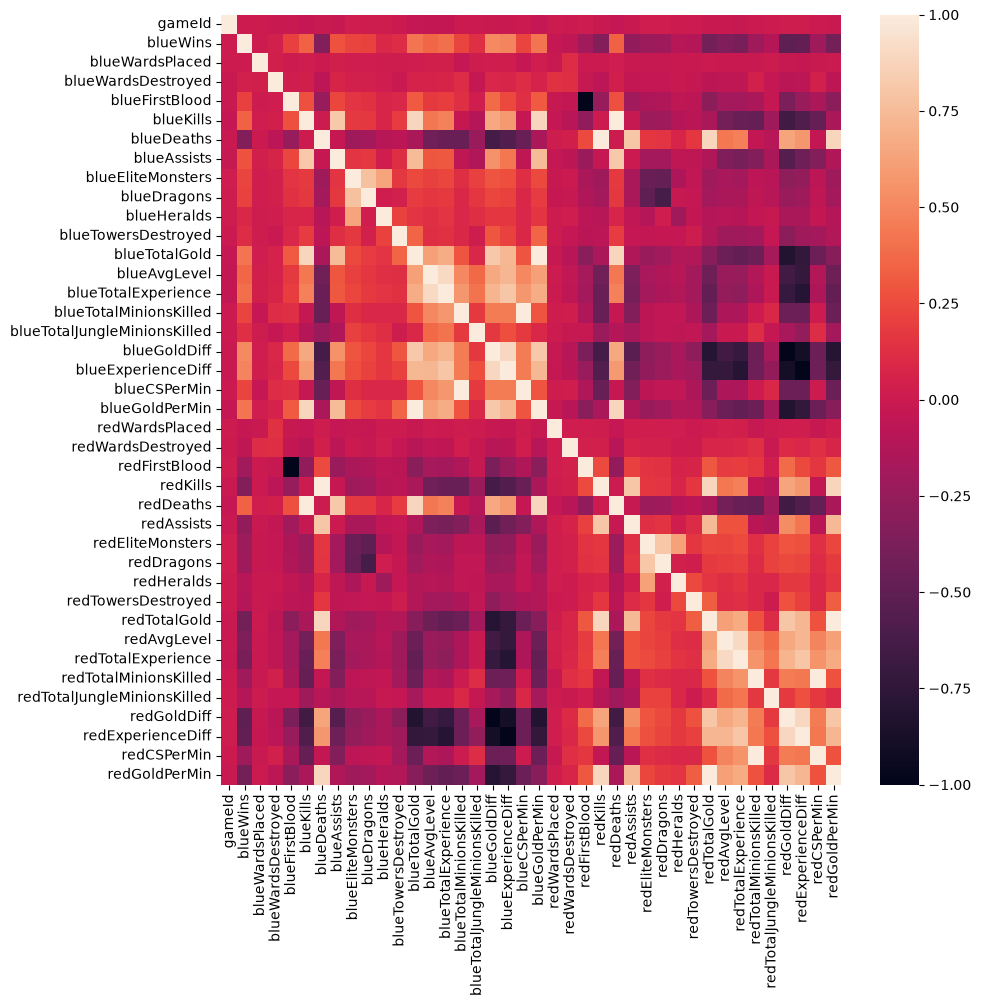

In [13]:
fig = plt.figure(figsize=(10, 10))
sns.heatmap(df.corr())
plt.show()

In [14]:
"""
 ↓ 밝은쪽이 1.0   어두운쪽이 -1.0

● gameid 는 어떤값과도 연관성이 없기 때문에 corr 값이 거의 0 임을 확인할수 있다
   -> 맨 위의 가로 라인,  맨 왼쪽의 세로 라인

● 우리의 관심 대상은 '승패 에 영향을 주는 요소' 다
  -> 가령, 'blueWins' 와 관련이 있는 것들을 무엇일까?
    위의 heatmap 은 모든 컬럼에 대해서 계산된 결과라 보기 힘들다
    blueWins 에 대해서만 보도록 해보자 ↓

● sns.headmap() 의 annot=True 를 주면, 수치값도 표현된다.
"""
None

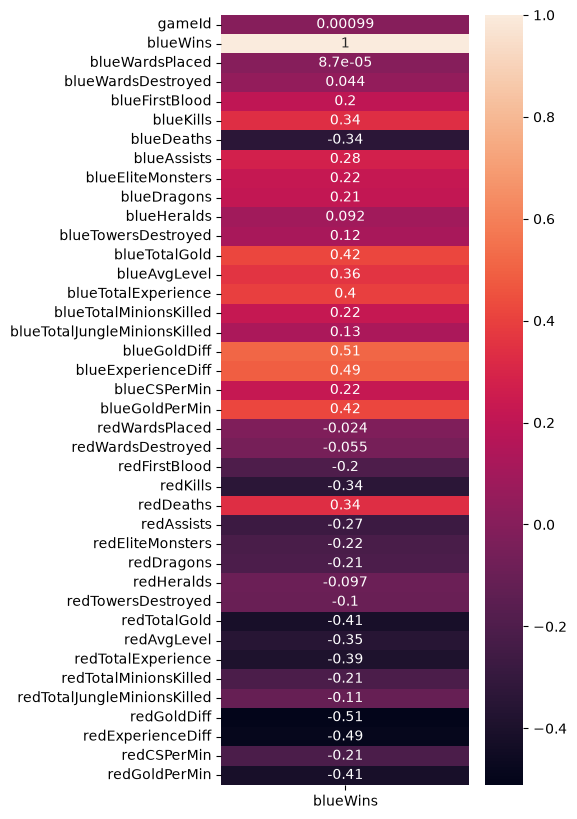

In [15]:
fig = plt.figure(figsize=(4, 10))
sns.heatmap(df.corr()[['blueWins']], annot=True)
plt.show()

In [16]:
"""
↑ 관찰
● gameId 0.00099 <-- 별 관련성 없다

● blueWardsPlaced  <--
  이 또한 별로 연관성 없다.  다들 ward 많이 박아두니까 그런가? 승자나 패자나 설치수에 큰 차이 없을듯 합니다

● blueKills, blueDeaths 는 각각 0.34, -0.34  <- 거의 동등한 정도로 반대 영향을 준다.
   (blue 가 죽인횟수)  (blue 가 죽임당한 횟수)

● blueTotalGold 0.42,
  blueGoldDiff 0.51  <-- 꽤 큰 값이 나온다.
     즉 red팀이 gold 를 못 먹게 하고 blue 가 gold 를 더 많이 먹는게 승패에 더 큰 영향을 준다! 라는 뜻.

  blueGoldPerMin  0.42  이 또한 큰 영향


corr() 과 headmap() 으로 보아도 상당히 많은+재미있는 정보들을 관찰해볼수 있다
"""
None

In [17]:
df.corr()[['blueExperienceDiff', 'redExperienceDiff']]

,blueExperienceDiff,redExperienceDiff
gameId,-0.012315,0.012315
blueWins,0.489558,-0.489558
blueWardsPlaced,0.027943,-0.027943
blueWardsDestroyed,0.077946,-0.077946
blueFirstBlood,0.240665,-0.240665
blueKills,0.583730,-0.583730
blueDeaths,-0.577613,0.577613
blueAssists,0.437002,-0.437002
blueEliteMonsters,0.263991,-0.263991
blueDragons,0.211496,-0.211496


In [18]:
"""
↑ [관찰]

   'blueKills'와 'redDeaths'  는 동일
   'blueDeaths' 와 'redKills'  는 동일


 + 혹은 - 로 나타나는 관계가 있다
    'blueGoldDiff', 'redGoldDiff'
    'blueExperienceDiff', 'redExperienceDiff'

즉, 정확히 반대로 나타나는 데이터들
이 상태에서 LinearRegression 이나 LogisticRegression 을 하게 되면
multi-collinearity 가 발생할수 있다.

즉 'blueGoldDiff' 와 'redGoldDiff' 는 음/양 완전히 반대인 상태에서 학습이 양쪽 방향으로 진행되면서
원하는 대로의 학습이 진행되지 않는 문제들이 발생할수 있다.

이런 경우 multi-colinearity 를 배제하여 훈련시킬 필요가 있다.

"""
None

# 수치형 데이터 분석

In [20]:
df.columns

Index(['gameId', 'blueWins', 'blueWardsPlaced', 'blueWardsDestroyed',
       'blueFirstBlood', 'blueKills', 'blueDeaths', 'blueAssists',
       'blueEliteMonsters', 'blueDragons', 'blueHeralds',
       'blueTowersDestroyed', 'blueTotalGold', 'blueAvgLevel',
       'blueTotalExperience', 'blueTotalMinionsKilled',
       'blueTotalJungleMinionsKilled', 'blueGoldDiff', 'blueExperienceDiff',
       'blueCSPerMin', 'blueGoldPerMin', 'redWardsPlaced', 'redWardsDestroyed',
       'redFirstBlood', 'redKills', 'redDeaths', 'redAssists',
       'redEliteMonsters', 'redDragons', 'redHeralds', 'redTowersDestroyed',
       'redTotalGold', 'redAvgLevel', 'redTotalExperience',
       'redTotalMinionsKilled', 'redTotalJungleMinionsKilled', 'redGoldDiff',
       'redExperienceDiff', 'redCSPerMin', 'redGoldPerMin'],
      dtype='str')

<Axes: xlabel='blueGoldDiff', ylabel='Count'>

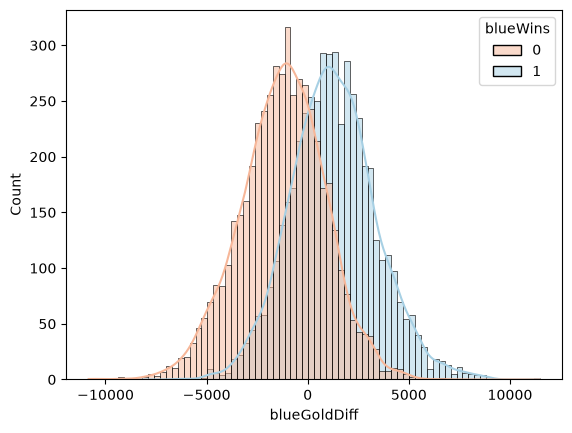

In [19]:
sns.histplot(x='blueGoldDiff', data=df, hue='blueWins', kde=True, palette='RdBu')

In [ ]:
"""
↑ 관찰
굉장히 뚜렷한 쌍봉 형태의 히스토 그램
blue 가 이긴경우 (blueWins 가 1), red 가 이긴경우 (blueWins 가 0)

blueGoldDiff 는 승패를 가르는데, 굉장히 좋은 feature 라고 볼수 있다.
매우 교과서 적인 데이터!

"""
None


<Axes: xlabel='blueKills', ylabel='Count'>

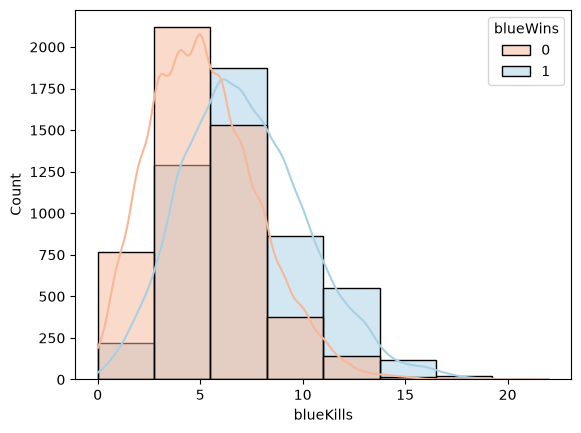

In [23]:
sns.histplot(x='blueKills', data=df, hue='blueWins', kde=True, palette='RdBu', bins=8)

In [ ]:
"""
blue가 이긴경우 (blueWins 가 1) 파란색.

직전의 blueGoldDiff 보다는 좀 덜 교과서적인 분포를 보이고 있다.
그래도 어느정도는 blue팀 승패를 가르는데는 효과적인 feature 라고 볼수 있다.
"""
None

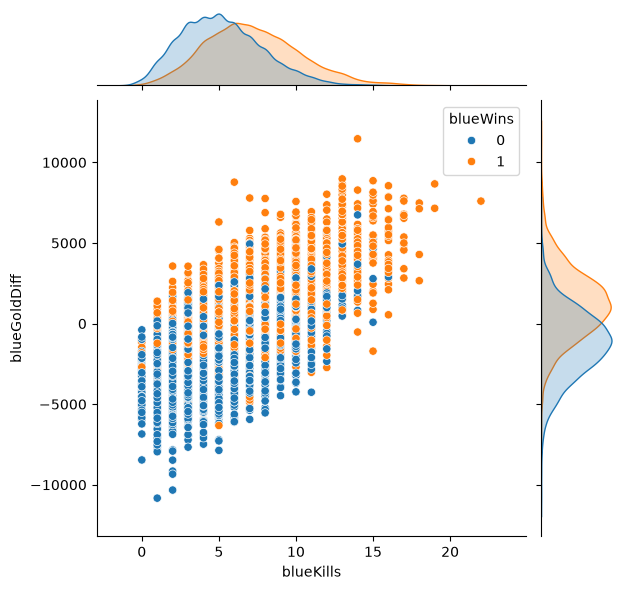

In [28]:
sns.jointplot(x='blueKills', y='blueGoldDiff', data=df, hue='blueWins')

In [ ]:
"""
↑ 관찰
blueGoldDiff 와 blueKills 는 어느정도 상관성을 가진다고는 볼수 있다
- 상관성이 높을수록 거의 대각선 일자형 분포를 가지게 된다.
지금은 어느정도 옆으로도 퍼지는 형태를 띄고 있다.

blueWins 값은 각각 갈라지는 위치가 있는 상보적인 관계.
두개의 feature 의 콜라보가 기대되는 상황

"""
None


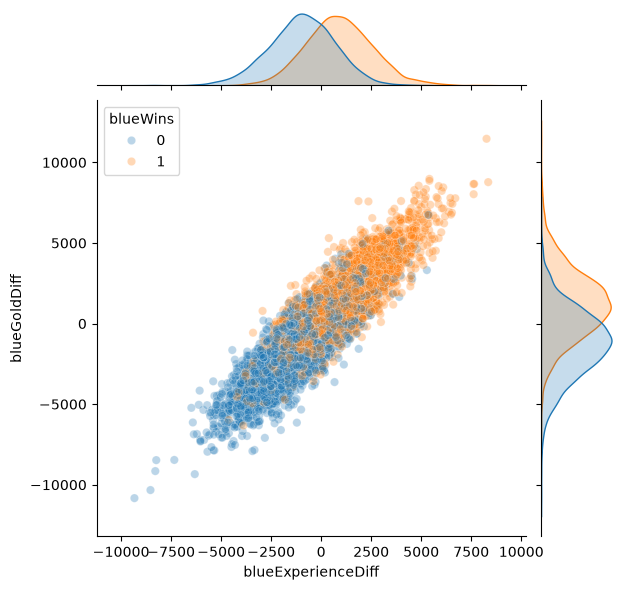

In [32]:
sns.jointplot(x='blueExperienceDiff', y='blueGoldDiff', data=df, hue='blueWins', alpha=0.3)

In [30]:
df.columns

Index(['gameId', 'blueWins', 'blueWardsPlaced', 'blueWardsDestroyed',
       'blueFirstBlood', 'blueKills', 'blueDeaths', 'blueAssists',
       'blueEliteMonsters', 'blueDragons', 'blueHeralds',
       'blueTowersDestroyed', 'blueTotalGold', 'blueAvgLevel',
       'blueTotalExperience', 'blueTotalMinionsKilled',
       'blueTotalJungleMinionsKilled', 'blueGoldDiff', 'blueExperienceDiff',
       'blueCSPerMin', 'blueGoldPerMin', 'redWardsPlaced', 'redWardsDestroyed',
       'redFirstBlood', 'redKills', 'redDeaths', 'redAssists',
       'redEliteMonsters', 'redDragons', 'redHeralds', 'redTowersDestroyed',
       'redTotalGold', 'redAvgLevel', 'redTotalExperience',
       'redTotalMinionsKilled', 'redTotalJungleMinionsKilled', 'redGoldDiff',
       'redExperienceDiff', 'redCSPerMin', 'redGoldPerMin'],
      dtype='str')

# 범주형 데이터 분석

In [33]:
df.corr()[['blueWins']]

,blueWins
gameId,0.000985
blueWins,1.000000
blueWardsPlaced,0.000087
blueWardsDestroyed,0.044247
blueFirstBlood,0.201769
blueKills,0.337358
blueDeaths,-0.339297
blueAssists,0.276685
blueEliteMonsters,0.221944
blueDragons,0.213768


In [34]:
# 승패와 상관성이 높은 분류형 feature 하나를 골라 분석해봅시다

# corr() 결과를 다시 보면 -> blueDragons 가 상관성이 좀 높아 보인다
# blueDragons 는 dtype 이 숫자 타입이고, 실제 게임에선 dragon 은 1 이상으로도 잡을수 있긴 하다만.

# 주어진 데이터에서는 0, 1 두가지만 존재함

df.blueDragons.value_counts()

# blueDragons 

blueDragons
0    6303
1    3576
Name: count, dtype: int64

<Axes: xlabel='blueDragons', ylabel='count'>

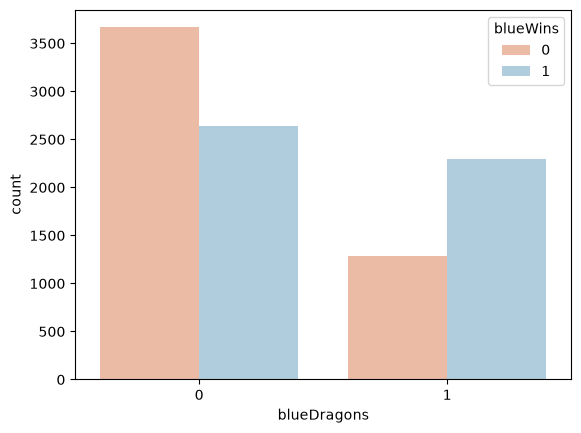

In [35]:
sns.countplot(x='blueDragons', data=df, hue='blueWins', palette='RdBu')

<Axes: xlabel='redDragons', ylabel='count'>

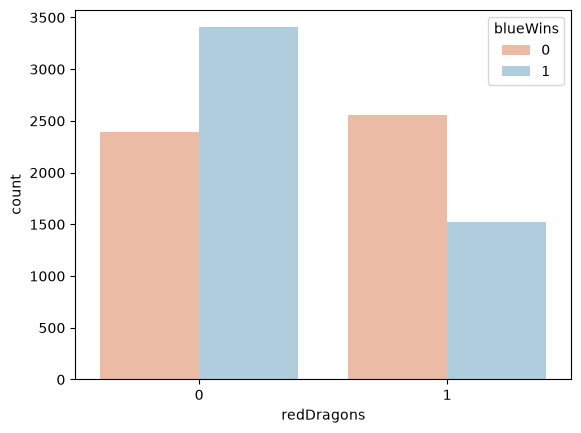

In [36]:
sns.countplot(x='redDragons', data=df, hue='blueWins', palette='RdBu')

In [ ]:
"""
red 가 dragon 을 잡지 못한 경우 (왼쪽) 와 아닌 경우 (오른쪽)
red 가 이긴 경우 (빨간색)의 차이는 먼저 blueDragons 의 경우보다 훨씬 작은거 같다.


이를통해 blue가 드래곤을 잡는 것과 red가 드래곤을 잡는 것은 '비대칭'적인 것을 발견할수 있다
게임의 밸런스가 좀 맞지 않는 부분이 있어 보임. (지형편자.)
"""
None


<Axes: xlabel='blueFirstBlood', ylabel='count'>

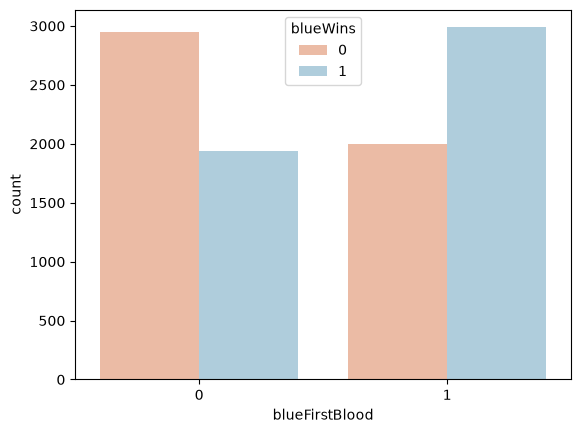

In [37]:
sns.countplot(x='blueFirstBlood', data=df, hue='blueWins', palette='RdBu')

In [ ]:
"""
좌우를 보면 굉장히 균형이 잘 맞아 있는걸 볼수 잇다.

blueDragons 의 경우 양측이 치우친 통계가 나왔는데
blueFirstBlood 의 경우 양 경우가 균등하게 결과가 나옴.  (큰 차이가 없슴)

즉, FirstBlood 를 낸것에 대해서는 양측에서 딱히 승패의 유불리에 영향을 주지 못했다는 뜻입니다.

"""
None